In [1]:
from algs.cd_poly import CDPolynomial
from algs.cd_cheb import *

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd

In [2]:
mu = np.zeros(2)
sig = np.array([[.08, .05,], 
                [.05, .08]])

z = np.random.multivariate_normal(mu, sig, size=1000)

(array([  6.,  13.,  83., 260., 430., 514., 392., 212.,  67.,  23.]),
 array([-0.99569134, -0.80942445, -0.62315755, -0.43689066, -0.25062376,
        -0.06435687,  0.12191003,  0.30817693,  0.49444382,  0.68071072,
         0.86697761]),
 <BarContainer object of 10 artists>)

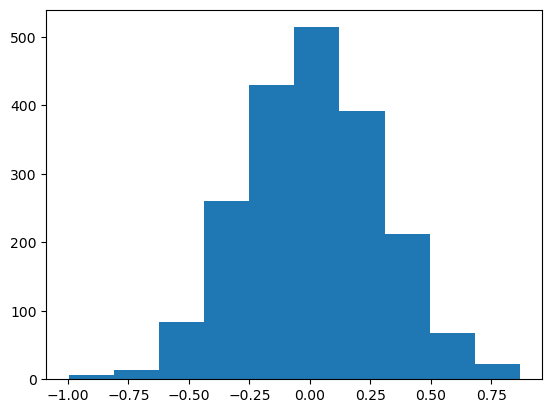

In [3]:
plt.hist(z.flatten())

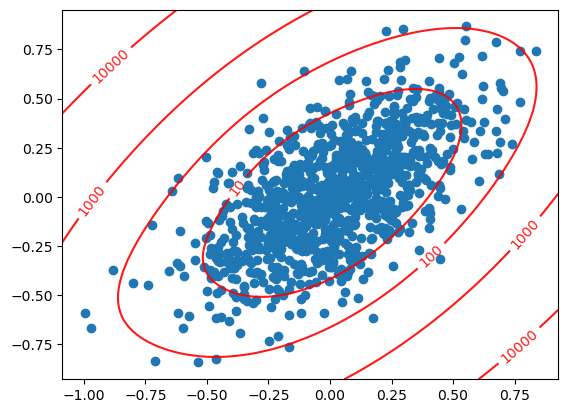

In [11]:
p = CDPolynomial(z, degree=3)
pp = CDPolyCheb(z, degree=3)

plt.scatter(*z[:, :2].T)

#p.plot(plt.gca())
pp.plot(plt.gca(), colors='red')

In [13]:
d = 3

%time p = CDPolynomial(z, degree=d, verbose=True)
%time pp = CDPolyCheb(z, degree=d, verbose=True)

Data monomials shape: (1000, 10)
Moment matrix cond num: 1.611964e+04
Empirical mean of CD poly: 9.999999999999998
CPU times: user 1.58 ms, sys: 1.09 ms, total: 2.66 ms
Wall time: 1.64 ms
Data monomials shape: (1000, 10)
Moment matrix cond num: 2.552739e+04
Empirical mean of CD poly: 10.0
CPU times: user 161 ms, sys: 5.19 ms, total: 167 ms
Wall time: 166 ms


In [50]:
z = np.load('data/coeffs_dct.npy', 'r')

z = scaler.fit_transform(z[:, :8])

In [56]:
d = 4
p = CDPolynomial(z, degree=d, verbose=True)
pcheb = CDPolyCheb(z, degree=d)

Data monomials shape: (10000, 495)
Moment matrix cond num: 3.149420e+11
Empirical mean of CD poly: 495.00000000000074
Data monomials shape: (10000, 495)
Moment matrix cond num: 1.111284e+11
Empirical mean of CD poly: 495.0021057128906


In [14]:
n = 10000
u = np.random.randn(n, 2)
z = np.cos(np.pi * u) # z ~ 1 / (pi * sqrt(1 - z^2))
#z = u

In [16]:
pcheb = CDPolyCheb(z, degree=4, verbose=True)

Data monomials shape: (10000, 15)
Moment matrix cond num: 4.167762e+00
Empirical mean of CD poly: 15.000015258789062


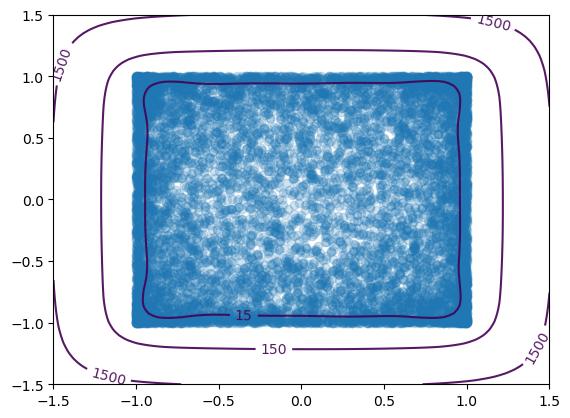

In [19]:
plt.scatter(*z.T, alpha=.2)
plt.xlim(-1.5, 1.5)
plt.ylim(-1.5, 1.5)

pcheb.plot(plt.gca())

In [50]:
z = np.random.randn(10000, 4)
d = 10

In [51]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler((-1, 1))
z_trans = scaler.fit_transform(z)

In [52]:
p = CDPolynomial(z, degree=d, verbose=True)
pp = CDPolyCheb(z, degree=d, verbose=True)

Data monomials shape: (10000, 1001)
Moment matrix cond num: 1.203306e+12
Empirical mean of CD poly: 1001.0
Data monomials shape: (10000, 1001)
Moment matrix cond num: 1.732675e+16
Empirical mean of CD poly: 1001.0010986328125


In [53]:
p = CDPolynomial(z_trans, degree=d, verbose=True)
pp = CDPolyCheb(z_trans, degree=d, verbose=True) # scaling to [-1, 1] seems more beneficial for Chebyshev

Data monomials shape: (10000, 1001)
Moment matrix cond num: 2.884411e+12
Empirical mean of CD poly: 1001.0
Data monomials shape: (10000, 1001)
Moment matrix cond num: 5.951959e+11
Empirical mean of CD poly: 1001.0149536132812


Conjecture: if the data is scaled to $[-1, 1]^d$, then Chebyshev will always eventually be better conditioned than standard monomial, as long as degree is sufficiently large.